##BanglaBert BiLSTM on Bangla Sentiment

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/The Datasets./Social Media Engagement Dataset.csv")
df.head(3)

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,translated_text_content,hashtags,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকা...,#Food,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,স্প্রিংব্লাস্ট ২০২৫-এর সময় মাইক্রোসফট সারফেস ...,"#MustHave, #Food",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী?...,"#Promo, #Food, #Trending",...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4


In [4]:
selected_columns = ['text_content', 'translated_text_content', 'sentiment_label']
df = df[selected_columns]

In [5]:
pd.set_option('display.max_colwidth', None)
print(df['translated_text_content'].head(20))

0                                                                 গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকালের সেরা কেনাকাটা। #খাবার আপনার মতামত শুনতে সত্যিই আগ্রহী!
1                                                    স্প্রিংব্লাস্ট ২০২৫-এর সময় মাইক্রোসফট সারফেস ল্যাপটপের একটা বিজ্ঞাপন দেখলাম। টাকার মূল্য নেই। #অবশ্যই খাওয়া, #খাবার।
2                                                              নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী? #প্রচার, #খাবার, #ট্রেন্ডিং আপনার মতামত শুনতে সত্যিই আগ্রহী!
3                                                                                                  পেপসির নতুন ডায়েট পেপসি দেখে হতাশ! মান নিয়ে হতাশ। #পর্যালোচনা, #টেকসই
4                                                                 টয়োটার করোলাটা ট্রাই করলাম। সত্যিই খুব ভালো লেগেছে। #স্বাস্থ্য, #ভ্রমণ আপনার মতামত শুনতে সত্যিই আগ্রহী!
5                                      নাইকি পাওয়াররিলিজ তো খুবই খারাপ! এরপর কী আসছে তা দেখার জন্য অধীর আগ্রহে অপেক্ষা করছি। #ছাড় আপনার অভিজ্ঞত

In [6]:
df['sentiment_label'].value_counts()

,count
sentiment_label,
Negative,4854
Positive,4839
Neutral,2307


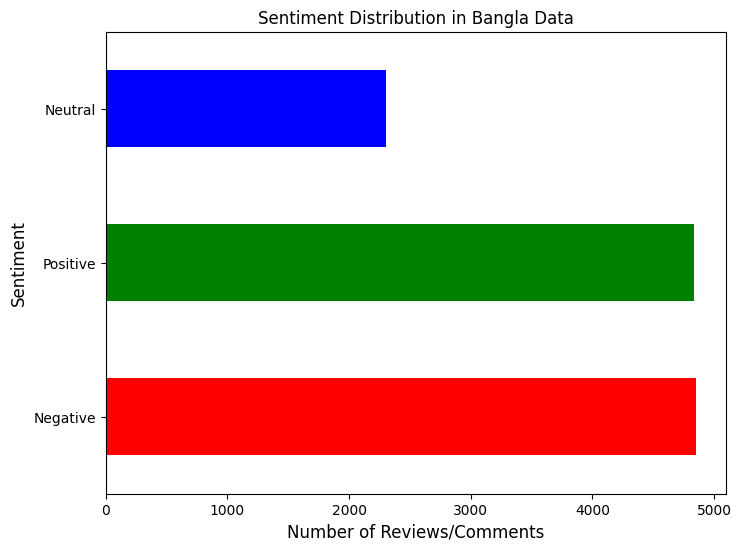

In [7]:
plt.figure(figsize=(8, 6))
df['sentiment_label'].value_counts().plot(kind='barh', color=['red', 'green', 'blue'])
plt.title('Sentiment Distribution in Bangla Data')
plt.xlabel('Number of Reviews/Comments',fontsize=12)
plt.ylabel('Sentiment',fontsize=12)
plt.show()

In [8]:
df.isnull().values.any()

np.False_

In [9]:
df.isnull().sum()

,0
text_content,0
translated_text_content,0
sentiment_label,0


In [10]:
import re
import unicodedata
import pandas as pd

def clean_bangla_text(text):
    """
    Standardizes and cleans Bengali/English text for BERT-BiLSTM training.
    Removes URLs, mentions, and all noise following hashtags.
    """
    if pd.isnull(text):
        return ""

    # 1. Normalize Unicode to ensure character consistency
    text = unicodedata.normalize('NFKC', str(text))

    # 2. Remove URLs and Social Media Mentions (@user)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\S+', '', text)

    # 3. Truncate at the first Hashtag
    # Based on dataset observation: everything from the first '#' onwards is noise
    if '#' in text:
        text = text.split('#')[0]

    # 4. Filter characters: Keep Bengali, English, Digits, and essential punctuation
    # Preserving punctuation like '।' and '.' helps BERT understand context
    text = re.sub(r'[^\u0980-\u09FFa-zA-Z0-9\s.,!?।]', ' ', text)

    # 5. Final whitespace normalization
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [11]:
df['clean_text'] = df['translated_text_content'].apply(clean_bangla_text)

In [12]:
pd.set_option('display.max_colwidth', None)
print(df[['translated_text_content', 'clean_text']].head(20))

                                                                                                                                                 translated_text_content  \
0                                                               গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকালের সেরা কেনাকাটা। #খাবার আপনার মতামত শুনতে সত্যিই আগ্রহী!   
1                                                  স্প্রিংব্লাস্ট ২০২৫-এর সময় মাইক্রোসফট সারফেস ল্যাপটপের একটা বিজ্ঞাপন দেখলাম। টাকার মূল্য নেই। #অবশ্যই খাওয়া, #খাবার।   
2                                                            নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী? #প্রচার, #খাবার, #ট্রেন্ডিং আপনার মতামত শুনতে সত্যিই আগ্রহী!   
3                                                                                                পেপসির নতুন ডায়েট পেপসি দেখে হতাশ! মান নিয়ে হতাশ। #পর্যালোচনা, #টেকসই   
4                                                               টয়োটার করোলাটা ট্রাই করলাম। সত্যিই খুব ভালো লেগেছে। #স্বাস্থ্য, #ভ্রমণ আপনা

In [13]:
from sklearn.model_selection import train_test_split

x = df['clean_text']
y = df['sentiment_label']


x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

x_train, x_valid, y_train, y_valid = train_test_split(x_train_full, y_train_full, test_size=0.15, random_state=42,  stratify=y_train_full)


print(f"Training set size: {len(x_train)}")
print(f"Validation set size: {len(x_valid)}")
print(f"Testing set size: {len(x_test)}")



Training set size: 8160
Validation set size: 1440
Testing set size: 2400


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)
y_test_enc  = le.transform(y_test)

print("Classes:", le.classes_)
print("Number of classes:", len(le.classes_))

Classes: ['Negative' 'Neutral' 'Positive']
Number of classes: 3


In [15]:
# Sequence length
lengths = [len(seq) for seq in x_train]

print("Max length:          ", max(lengths))
print("Min length:          ", min(lengths))
print("Mean length:         ", int(np.mean(lengths)))
print("Median length:       ", int(np.median(lengths)))
print("95th percentile:     ", int(np.percentile(lengths, 95)))
print("99th percentile:     ", int(np.percentile(lengths, 99)))

Max length:           121
Min length:           32
Mean length:          74
Median length:        74
95th percentile:      100
99th percentile:      110


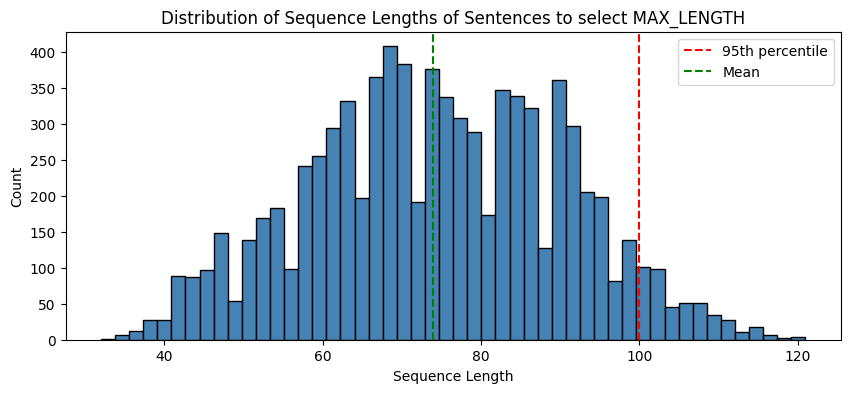

In [16]:
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black')
plt.axvline(int(np.percentile(lengths, 95)), color='red',
            linestyle='--', label='95th percentile')
plt.axvline(int(np.mean(lengths)), color='green',
            linestyle='--', label='Mean')
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.title("Distribution of Sequence Lengths of Sentences to select MAX_LENGTH")
plt.legend()
plt.show()

In [17]:
!pip install transformers torch -q

In [18]:
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset, DataLoader

MODEL_NAME = "sagorsarker/bangla-bert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128

class BanglaDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.tolist()
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = BanglaDataset(x_train.reset_index(drop=True), y_train_enc)
valid_dataset = BanglaDataset(x_valid.reset_index(drop=True), y_valid_enc)
test_dataset  = BanglaDataset(x_test.reset_index(drop=True),  y_test_enc)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset,  batch_size=16)

print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Train batches: 510
Valid batches: 90


In [19]:
import torch
import torch.nn as nn
from transformers import AutoModel
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

class BanglaBERT_BiLSTM(nn.Module):
    def __init__(self, num_classes=3, lstm_hidden=128, lstm_layers=2, dropout=0.3):
        super().__init__()

        self.bert = AutoModel.from_pretrained("sagorsarker/bangla-bert-base")

        self.bilstm = nn.LSTM(
            input_size=768,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = bert_out.last_hidden_state        # (batch, seq_len, 768)

        lstm_out, _ = self.bilstm(sequence_output)          # (batch, seq_len, 256)


        mask = attention_mask.unsqueeze(-1).float()         # (batch, seq_len, 1)
        sum_out = (lstm_out * mask).sum(dim=1)              # (batch, 256)
        count   = mask.sum(dim=1).clamp(min=1e-9)          # (batch, 1)
        cls_out = sum_out / count                           # (batch, 256)

        out = self.dropout(cls_out)
        logits = self.classifier(out)                       # (batch, num_classes)
        return logits


model = BanglaBERT_BiLSTM(num_classes=len(le.classes_)).to(device)
print(model)


Device: cuda


model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BanglaBERT_BiLSTM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(102025, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [20]:
# ✅ FIX 2: Class Weight — imbalanced data handle করার জন্য
classes = np.unique(y_train_enc)
weights = compute_class_weight('balanced', classes=classes, y=y_train_enc)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)



optimizer = AdamW([
    {'params': model.bert.parameters(),       'lr': 2e-5,  'weight_decay': 0.01},
    {'params': model.bilstm.parameters(),     'lr': 1e-3,  'weight_decay': 0.01},
    {'params': model.classifier.parameters(), 'lr': 1e-3,  'weight_decay': 0.01},
])



EPOCHS = 15

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

best_val_acc = 0
history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    train_acc  = correct / total
    train_loss = total_loss / len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch in valid_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item()
            preds        = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_acc  = val_correct / val_total
    val_loss = val_loss / len(valid_loader)

    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')
        print("  ✔ Best model saved")

Epoch 1/15 | Train Loss: 0.4217 Acc: 81.41% | Val Loss: 0.1299 Acc: 92.92%
  ✔ Best model saved
Epoch 2/15 | Train Loss: 0.1261 Acc: 93.28% | Val Loss: 0.1211 Acc: 93.82%
  ✔ Best model saved
Epoch 3/15 | Train Loss: 0.1385 Acc: 93.26% | Val Loss: 0.1271 Acc: 94.44%
  ✔ Best model saved
Epoch 4/15 | Train Loss: 0.1229 Acc: 93.68% | Val Loss: 0.1218 Acc: 93.89%
Epoch 5/15 | Train Loss: 0.1217 Acc: 93.58% | Val Loss: 0.1301 Acc: 94.51%
  ✔ Best model saved
Epoch 6/15 | Train Loss: 0.1209 Acc: 93.65% | Val Loss: 0.1154 Acc: 94.51%
Epoch 7/15 | Train Loss: 0.1204 Acc: 94.11% | Val Loss: 0.1205 Acc: 93.96%
Epoch 8/15 | Train Loss: 0.1176 Acc: 93.84% | Val Loss: 0.1182 Acc: 93.96%
Epoch 9/15 | Train Loss: 0.1173 Acc: 93.74% | Val Loss: 0.1294 Acc: 94.31%
Epoch 10/15 | Train Loss: 0.1255 Acc: 93.86% | Val Loss: 0.1225 Acc: 93.96%
Epoch 11/15 | Train Loss: 0.1197 Acc: 93.85% | Val Loss: 0.1217 Acc: 94.03%
Epoch 12/15 | Train Loss: 0.1207 Acc: 93.69% | Val Loss: 0.1223 Acc: 94.17%
Epoch 13/15 |

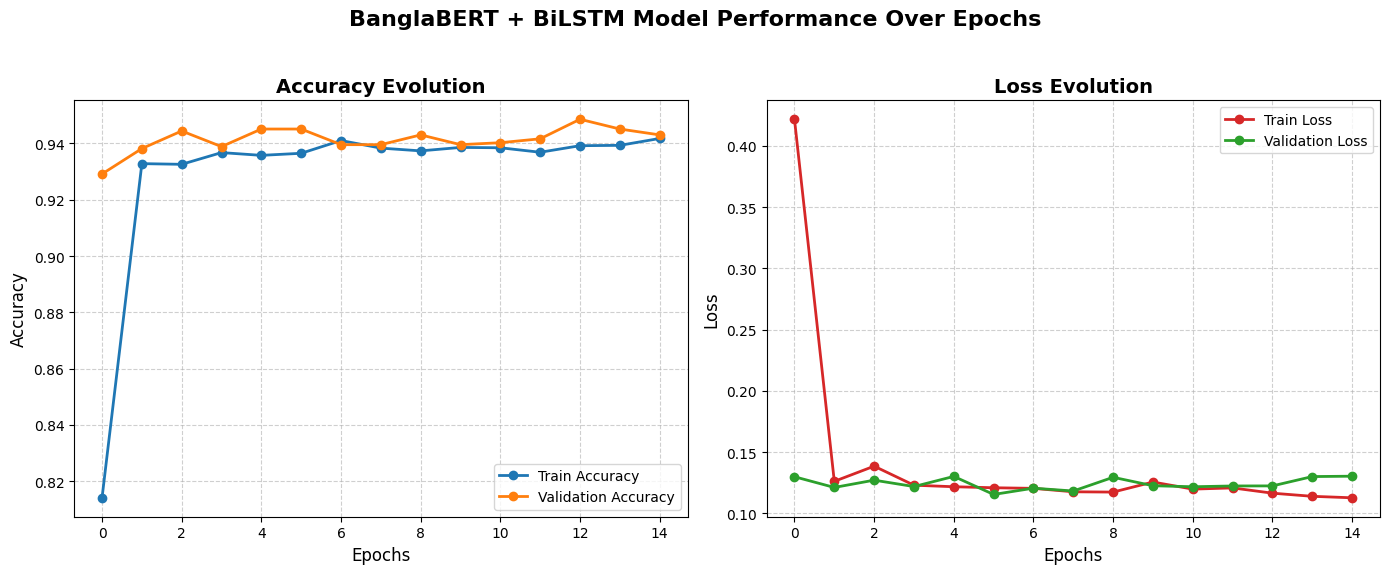

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.suptitle('BanglaBERT + BiLSTM Model Performance Over Epochs', fontsize=16, fontweight='bold')

# 1. (Accuracy Plot)
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2, color='#1f77b4')
plt.plot(history['val_acc'], label='Validation Accuracy', marker='o', linewidth=2, color='#ff7f0e')
plt.title('Accuracy Evolution', fontsize=14, fontweight='semibold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# 2(Loss Plot)
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2, color='#d62728')
plt.plot(history['val_loss'], label='Validation Loss', marker='o', linewidth=2, color='#2ca02c')
plt.title('Loss Evolution', fontsize=14, fontweight='semibold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])


plt.show()

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.92      0.94      0.93       971
     Neutral       0.99      0.89      0.94       461
    Positive       0.92      0.94      0.93       968

    accuracy                           0.93      2400
   macro avg       0.94      0.92      0.93      2400
weighted avg       0.93      0.93      0.93      2400



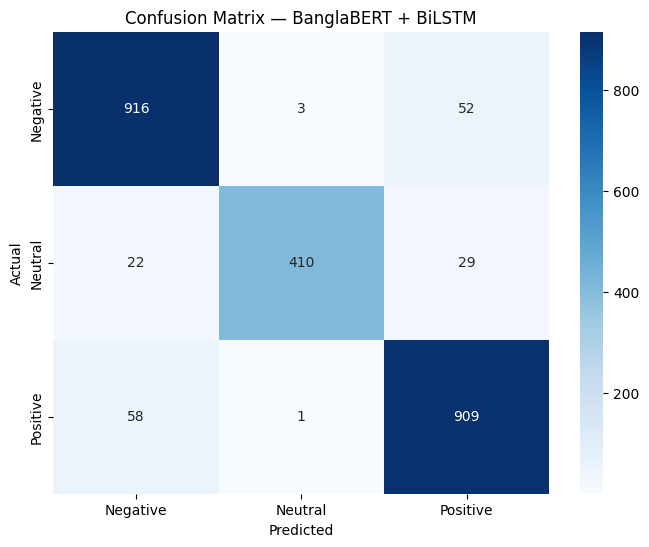

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load('best_model.pt'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids, attention_mask)
        preds   = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — BanglaBERT + BiLSTM')
plt.show()